# Hyperparameters

In [1]:
%load_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
from scipy import sparse
import scanpy as sc
import matplotlib.pyplot as plt
import os
import rpy2.robjects as ro

from dotenv import load_dotenv; load_dotenv()


from utils import preprocessing
from utils import DEG

from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

# ATTENTION: need for perpty of running jupternotbook
%matplotlib inline

PARALLEL_NEBULA_SCRIPT_PATH = os.getenv("PARALLEL_NEBULA_SCRIPT")

GENESET="003"
DATASET_FOLDER = f"/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_{GENESET}/depleted_versions"
TRUE_DEG_PATH = f"{DATASET_FOLDER}/../initial_perturbed/genes.csv"
QS_TMP_FOLDER = "/home/gdallagl/myworkdir/XDP/data/_old/nebula_tmp" # tmp folder where to save intemrediate results
METHOD_NAME = "PCA_nebula"
# adta that contins both H and D (with perturbations) BUT without depletion
ADATA_ALL = "/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/all_samples/depleted_dorsal_matrix/depleted_dorsal_matrix_all.h5ad"

save_df_PCs_path = f"{os.path.split(ADATA_ALL)[0]}/PCA/PCs_all.csv"
N_PCS_TO_USE = 6  # CHANGE THIS BASED ON YOUR ELBOW PLOT


# name of cell tyoe vauble annotaton to use in this analsys
CT_FOR_DEG_VARIABLE = "spn_type" #"Group_name",  "spn_type"
# name of Sample varibale
SAMPLE_VARIABLE = "donor_id"
# variable to test if differtially epxressed
CONTRAST_VARIABLE = "case_control"
# Level of contrat varibale to use as baseline
CONTRAST_BASELINE = "control"
# Level of contrat varibale to use as stimulated
CONTRAST_STIM = "case"

# Covariates to use for stat test
COVARIATES_FOR_DEG = ["Age.at.Death", "Sex", "PMI", "pct_mt", "pct_intronic",
                      ]
# libraru size col for  enbula
LIBRARY_SIZE_COL = "nCount_RNA"

# mitluple etst correction pvalue thr
ALPHA_MULTIPLE_TEST = 0.05
LOGFC_THR=0.1
PVAL_THR=0.05

# Calculate PCs for Healhty

same for all:
- depletion
- gene pertubrations

(healthy split always the same)

In [2]:
IS_FIRST_TIME = False

Loading
Splitting
Normalising
HVG
Scaling
PCA on Healthy
PCA on Diseased


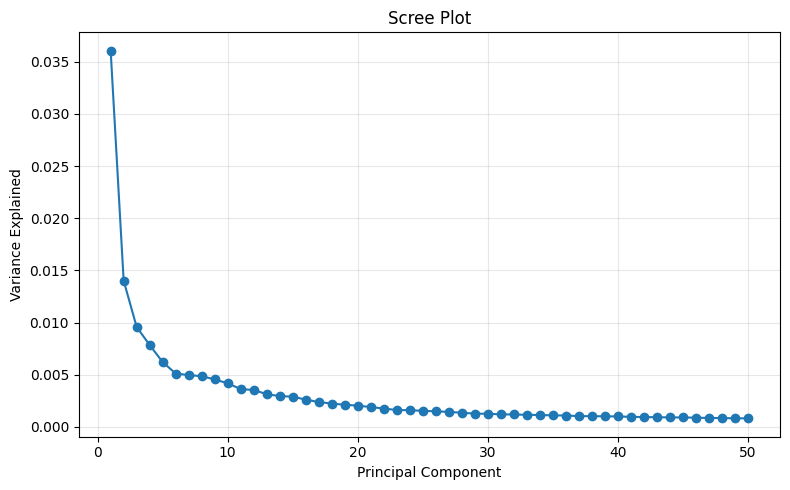

In [4]:
if IS_FIRST_TIME:
    print("Loading")
    adata_all = sc.read_h5ad(ADATA_ALL, backed="r")

    # Split
    print("Splitting")
    adata_healthy = adata_all[adata_all.obs[CONTRAST_VARIABLE] == CONTRAST_BASELINE].to_memory().copy()
    adata_diseased = adata_all[adata_all.obs[CONTRAST_VARIABLE] == CONTRAST_STIM].to_memory().copy()

    # Usual pipeline
    print("Normalising")
    sc.pp.normalize_total(adata_healthy, target_sum=1e4)
    sc.pp.log1p(adata_healthy)
    sc.pp.normalize_total(adata_diseased, target_sum=1e4)
    sc.pp.log1p(adata_diseased)

    # Find highly variable genes on HEALTHY only
    print("HVG")
    sc.pp.highly_variable_genes(adata_healthy, n_top_genes=3000)
    hvg = adata_healthy.var['highly_variable']

    # Subset both datasets to same genes
    adata_healthy = adata_healthy[:, hvg].copy()
    adata_diseased = adata_diseased[:, hvg].copy()
    assert np.all(adata_healthy.var_names == adata_diseased.var_names), "Gene order mismatch between healthy and diseased!"

    # Ectarct dense matrix
    X_healthy = adata_healthy.X.toarray() if hasattr(adata_healthy.X, 'toarray') else adata_healthy.X
    X_diseased = adata_diseased.X.toarray() if hasattr(adata_diseased.X, 'toarray') else adata_diseased.X

    # Scale using healthy statistics
    print("Scaling")
    scaler = StandardScaler(with_mean=True, with_std=True)
    X_healthy_scaled = scaler.fit_transform(X_healthy)

    # PCA on healthy
    print("PCA on Healthy")
    MAX_PCS_TO_COMPUTE = 50
    pca = PCA(n_components=MAX_PCS_TO_COMPUTE, random_state=42, svd_solver="full")
    healthy_pcs = pca.fit_transform(X_healthy_scaled)

    # Project diseased using healthy PCs
    print("PCA on Diseased")
    X_diseased_scaled = scaler.transform(X_diseased)  # Uses healthy mean/std!
    diseased_pcs = pca.transform(X_diseased_scaled)

    # Elbow plot
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, len(pca.explained_variance_ratio_) + 1), 
            pca.explained_variance_ratio_, 'o-')
    plt.xlabel('Principal Component')
    plt.ylabel('Variance Explained')
    plt.title('Scree Plot')
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.savefig(f"{os.path.split(ADATA_ALL)[0]}/PCA/elbow_plot.png", dpi=150)
    plt.show()

    # Save df with Pcs
    df_healthy = pd.DataFrame(
        healthy_pcs[:, :N_PCS_TO_USE],
        columns=[f'PC_{i+1}' for i in range(N_PCS_TO_USE)]
    )
    df_healthy.insert(0, 'barcode', adata_healthy.obs_names.values)
    df_diseased = pd.DataFrame(
        diseased_pcs[:, :N_PCS_TO_USE],
        columns=[f'PC_{i+1}' for i in range(N_PCS_TO_USE)]
    )
    df_diseased.insert(0, 'barcode', adata_diseased.obs_names.values)
    df_combined = pd.concat([df_healthy, df_diseased], ignore_index=True)
    df_combined.to_csv(save_df_PCs_path)

In [6]:
if IS_FIRST_TIME:

    # Extract loadings (genes × PCs)
    loadings = pca.components_.T  # Shape: (n_genes, n_components)

    # Create DataFrame
    df_loadings = pd.DataFrame(
        loadings,
        index= adata_healthy.var_names,
        columns=[f'PC_{i+1}' for i in range(loadings.shape[1])]
    )

    # Save
    df_loadings.to_csv(f"{os.path.split(ADATA_ALL)[0]}/PCA/gene_loadings.csv")

    #
    def get_top_genes_per_pc(pca, gene_names, n_top=20, n_pcs=6):
        """
        Create a simple DataFrame showing top N genes for each PC
        
        Returns DataFrame with columns: PC_1, PC_1_loading, PC_2, PC_2_loading, etc.
        """
        loadings = pca.components_.T  # (n_genes, n_PCs)
        
        result = {}
        
        for i in range(min(n_pcs, loadings.shape[1])):
            pc_name = f'PC_{i+1}'
            
            # Get absolute loadings
            abs_loadings = np.abs(loadings[:, i])
            
            # Get top N indices
            top_indices = np.argsort(abs_loadings)[::-1][:n_top]
            
            # Get gene names and actual loadings (with sign)
            top_genes = gene_names[top_indices]
            top_loadings = loadings[top_indices, i]
            
            # Add to result dictionary
            result[pc_name] = top_genes
            result[f'{pc_name}_loading'] = top_loadings
        
        # Create DataFrame
        df = pd.DataFrame(result)
        
        return df

    N_TOP_GENES = 20
    df_top_genes = get_top_genes_per_pc(
        pca, 
        gene_names=adata_healthy.var_names.values,
        n_top=N_TOP_GENES,
        n_pcs=N_PCS_TO_USE
    )
    display(df_top_genes)

,PC_1,PC_1_loading,PC_2,PC_2_loading,PC_3,PC_3_loading,PC_4,PC_4_loading,PC_5,PC_5_loading,PC_6,PC_6_loading
0,ZNF385B,0.081139,ARL17B,0.088057,DRD2,0.163312,MT-ND4L,0.130657,ADARB2,0.124235,CNTN3,0.100096
1,PLCB1,0.075056,CCDC144A,0.085014,PENK,0.145294,MT-CO1,0.130655,KCNJ6,0.112022,BACH2,-0.094848
2,OPCML,0.072744,CALM1,-0.080090,FIG4,0.143106,MT-ND4,0.124770,KIRREL1,0.109657,TET3,-0.088209
3,MME,0.072220,ACTB,-0.079432,FOXP2,-0.142071,MT-CYB,0.124467,GPC5,-0.106970,ANO2,0.088047
4,PDE10A,0.071429,EEF1A1,-0.077049,DRD1,-0.138834,MT-CO3,0.124442,KCNH5,0.101482,SEMA6D,-0.084849
5,SLC24A2,0.069485,THY1,-0.072832,CNTNAP3B,-0.138592,MT-CO2,0.122925,PARP8,0.098754,COL21A1,-0.083287
6,VSNL1,-0.068932,ACTG1,-0.072814,RELN,-0.134763,MT-ND5,0.121508,GDNF-AS1,0.096880,SYT6,-0.080429
7,PEG10,-0.068894,ENSG00000274422,0.071745,CNTNAP4,-0.134654,MT-ATP8,0.120404,TOX,0.093450,LOXHD1,-0.080229
8,ARHGAP6,-0.068753,CCDC59,0.070924,SOX1-OT,-0.133807,MT-ND1,0.116969,ENSG00000286328,0.093191,DDO,0.076941
9,GDA,-0.067272,GPR88,-0.070907,LINC01951,-0.132302,MT-ND2,0.115276,TAFA1,0.092185,LINC03000,0.076885


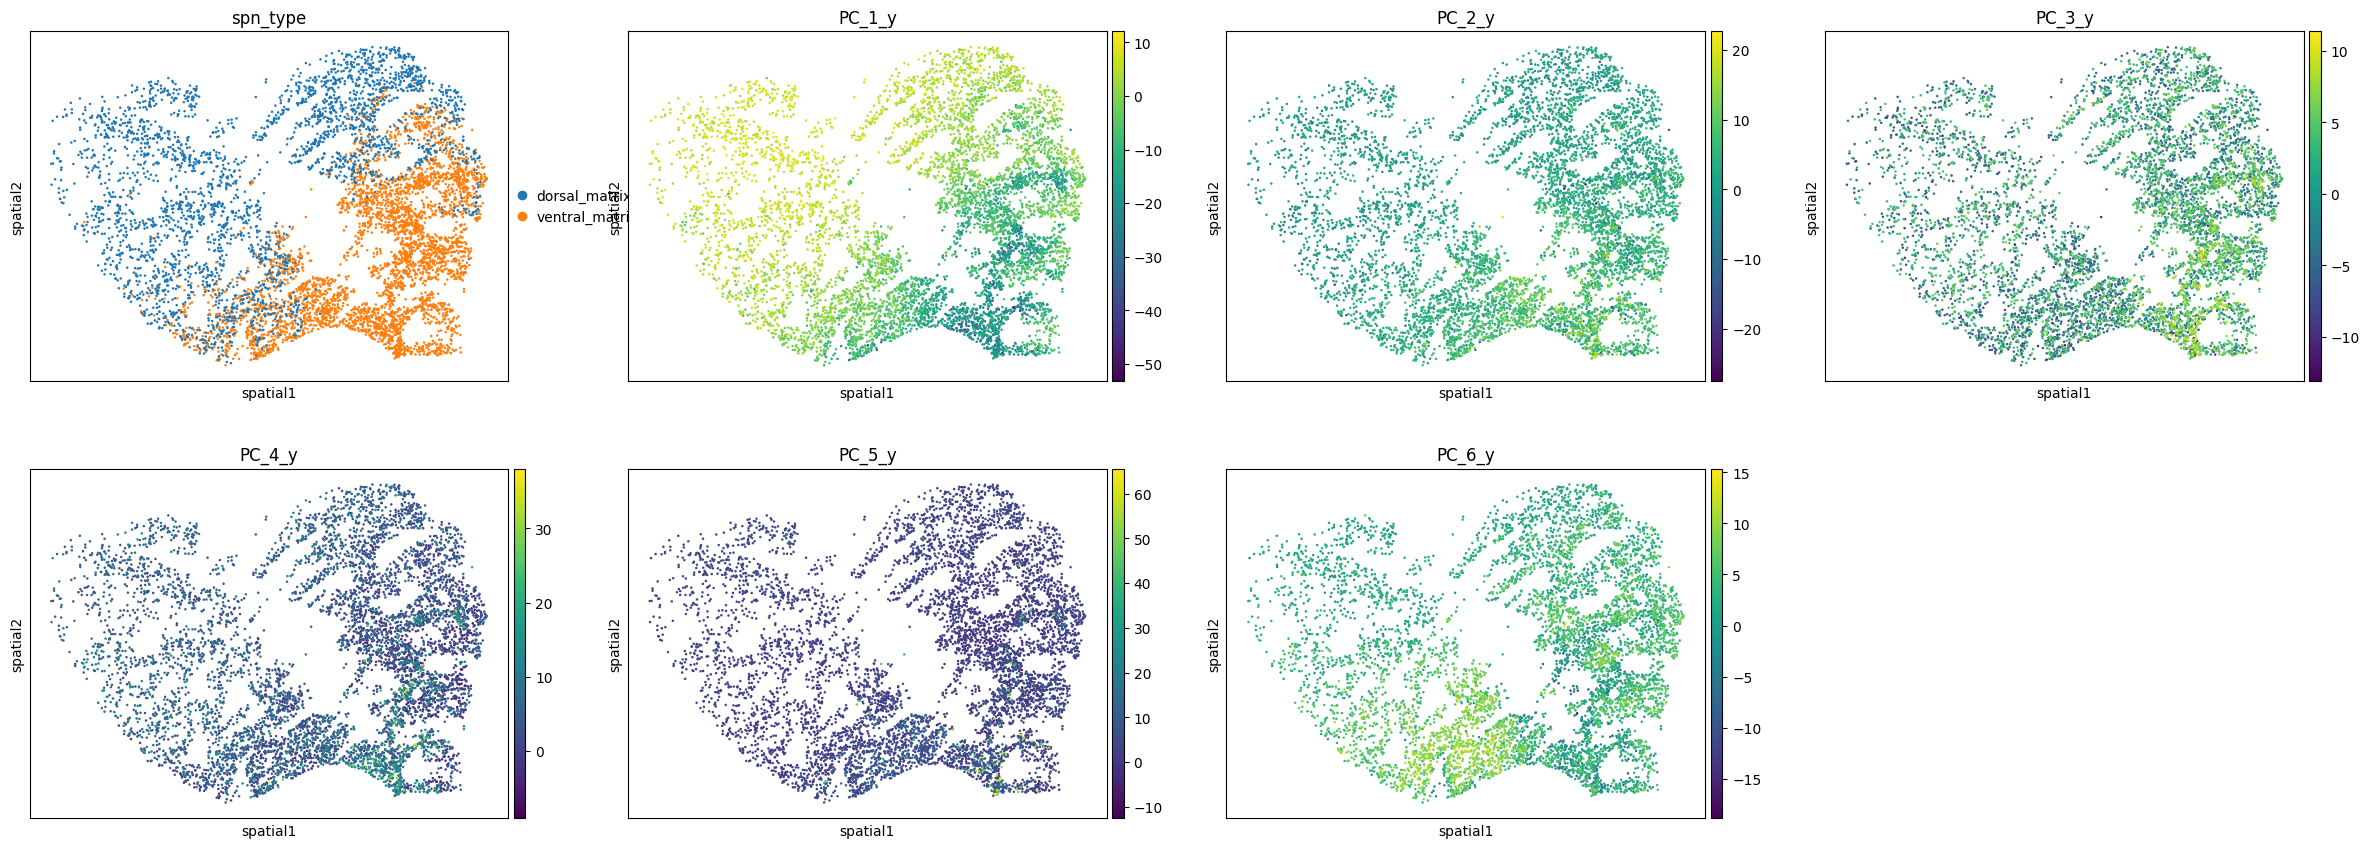

In [ ]:
if IS_FIRST_TIME:

    # Add to cov
    adata_all = sc.read_h5ad(ADATA_ALL, backed="r")

    adata_all.obs = adata_all.obs.merge(
        df_combined,
        left_index=True,
        right_on="barcode",
        how="left", 
        validate="one_to_one"
    )

    sample_id = "MS986638" #adata_pert_tmp.obs[adata_pert_tmp.obs[CONTRAST_VARIABLE] == CONTRAST_VARIABLE_DISEASED][DONOR_ID_VARIABLE].unique()[0]
    adata_s = adata_all[adata_all.obs[SAMPLE_VARIABLE] == sample_id].to_memory().copy()
    adata_s.obsm["spatial"] = adata_s.obs[["x", "y"]].values  # or .to_numpy()
    pcs = [f'PC_{i+1}_y' for i in range(N_PCS_TO_USE)]
    sc.pl.embedding(adata_s, basis="spatial", color=["spn_type", "Group_name", *pcs])
    del adata_s

~ case_control + PC_1 + PC_2 + PC_3 + PC_4 + PC_5 + PC_6 + Q("Age.at.Death") + Sex + PMI + pct_mt + pct_intronic


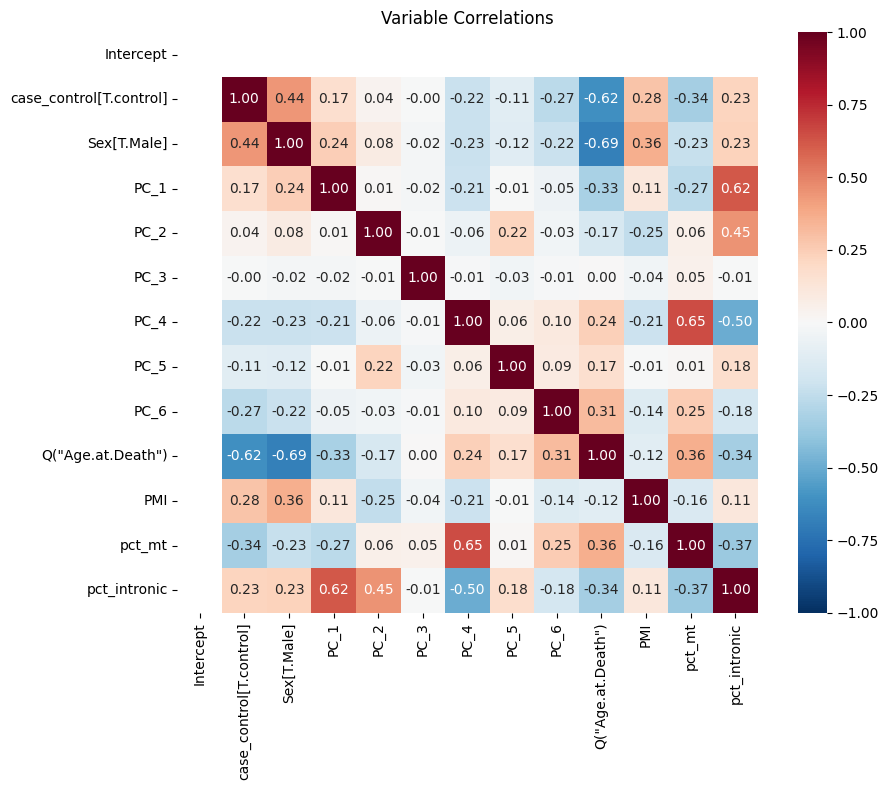

                   variable         VIF
0                 Intercept  679.555114
12             pct_intronic    3.765243
9         Q("Age.at.Death")    3.119066
6                      PC_4    2.399473
2               Sex[T.Male]    2.297126
3                      PC_1    2.250027
11                   pct_mt    2.167674
4                      PC_2    1.925763
1   case_control[T.control]    1.799112
10                      PMI    1.496051
8                      PC_6    1.223409
7                      PC_5    1.207092
5                      PC_3    1.010976

binary identifiability test. False


In [ ]:
# Check collinarity
if IS_FIRST_TIME:
    adata_all = sc.read_h5ad(ADATA_ALL, backed="r")
    df_combined = pd.read_csv(save_df_PCs_path, index_col="barcode").drop(columns=["Unnamed: 0"])
    #display(df_combined)

    pcs = [i for i in adata_all.obs.columns if "PC_" in i]
    adata_all.obs = adata_all.obs.drop(columns=pcs)

    #adata_all = adata_all[adata_all.obs[CONTRAST_VARIABLE] == CONTRAST_BASELINE].to_memory()

    adata_all.obs = adata_all.obs.merge(
        df_combined,
        left_index=True,
        right_index=True,
        how="left", 
        validate="one_to_one"
    )
    pcs = [f'PC_{i+1}' for i in range(N_PCS_TO_USE)]
    #display(adata_all.obs.columns)

    #adata_all.obs[[*pcs, *COVARIATES_FOR_DEG]].corr()
    DEG.check_corr_cov_in_design(adata_all, vars_in_formula=[CONTRAST_VARIABLE, *pcs, *COVARIATES_FOR_DEG], corr_thr=0.7, split=" + ")


# Create Covs and update .qs File

Each method will add its covaritates in .qs obj (needed for Nebula).

In [3]:
for dataset in sorted(os.listdir(DATASET_FOLDER), reverse=True):

    print(f"\n######\n Processing dataset: {dataset} \n######\n")

    dataset_path_h5ad = os.path.join(DATASET_FOLDER, dataset, f"{dataset}.h5ad")
    dataset_path_qs = os.path.join(DATASET_FOLDER, dataset, f"{dataset}.qs")
    cov_df_csv_path = save_df_PCs_path

    results_folder = os.path.join(DATASET_FOLDER, dataset, METHOD_NAME)
    os.makedirs(results_folder, exist_ok=True)

    ###################

    # Logic to calcualte specific Covs --> df with covariates (cov_df_csv_path)

    # For PCA all the same --> see above


    ##################

    preprocessing.add_metadata_to_qs(
        dataset_path_h5ad, cov_df_csv_path, file_type="h5ad", 
        col_name_contain="PC_", barcode_col="barcode")
    preprocessing.add_metadata_to_qs(
        dataset_path_qs, cov_df_csv_path, file_type="qs", 
        col_name_contain="PC_", barcode_col="barcode")

    #break


######
 Processing dataset: depleted_0.80_dorsal_matrix 
######

Processing h5ad file: /home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_003/depleted_versions/depleted_0.80_dorsal_matrix/depleted_0.80_dorsal_matrix.h5ad
Reading h5ad...
Reading new metadata...
Converting all columns (except barcode) to numeric...
Removing columns containing 'PC_': ['PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_5', 'PC_6', 'PC_7', 'PC_8', 'PC_9', 'PC_10', 'PC_11', 'PC_12', 'PC_13', 'PC_14', 'PC_15', 'PC_16', 'PC_17', 'PC_18', 'PC_19', 'PC_20', 'PC_21', 'PC_22', 'PC_23', 'PC_24', 'PC_25', 'PC_26', 'PC_27', 'PC_28', 'PC_29', 'PC_30']
Merging metadata...

Data types after merge:
  Unnamed: 0: int64
  PC_1: float64
  PC_2: float64
  PC_3: float64
  PC_4: float64
  PC_5: float64
  PC_6: float64

Saving h5ad...


2026-02-06 17:15:12 | [WARNING] R callback write-console: qs 0.27.3. Announcement: https://github.com/qsbase/qs/issues/103
  


✓ Done!
Processing qs file: /home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_003/depleted_versions/depleted_0.80_dorsal_matrix/depleted_0.80_dorsal_matrix.qs
[1] "Reading obj..."
[1] "Removing columns containing 'PC_': PC_1, PC_2, PC_3, PC_4, PC_5, PC_6, PC_7, PC_8, PC_9, PC_10, PC_11, PC_12, PC_13, PC_14, PC_15, PC_16, PC_17, PC_18, PC_19, PC_20, PC_21, PC_22, PC_23, PC_24, PC_25, PC_26, PC_27, PC_28, PC_29, PC_30"


2026-02-06 17:15:27 | [WARNING] R callback write-console: Loading required namespace: SeuratObject
  


[1] "Converting all columns (except barcode) to numeric..."
[1] "Saving..."


...

✓ Done!

######
 Processing dataset: depleted_0.10_dorsal_matrix 
######

Processing h5ad file: /home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_003/depleted_versions/depleted_0.10_dorsal_matrix/depleted_0.10_dorsal_matrix.h5ad
Reading h5ad...
Reading new metadata...
Converting all columns (except barcode) to numeric...
Removing columns containing 'PC_': ['PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_5', 'PC_6', 'PC_7', 'PC_8', 'PC_9', 'PC_10', 'PC_11', 'PC_12', 'PC_13', 'PC_14', 'PC_15', 'PC_16', 'PC_17', 'PC_18', 'PC_19', 'PC_20', 'PC_21', 'PC_22', 'PC_23', 'PC_24', 'PC_25', 'PC_26', 'PC_27', 'PC_28', 'PC_29', 'PC_30']
Merging metadata...

Data types after merge:
  Unnamed: 0: int64
  PC_1: float64
  PC_2: float64
  PC_3: float64
  PC_4: float64
  PC_5: float64
  PC_6: float64

Saving h5ad...
✓ Done!
Processing qs file: /home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_003/depleted_versions/depleted_0.10_dorsal_matrix/depleted_0.10_dorsal_matrix.qs
[1] "Reading obj..

2026-02-06 17:28:35 | [WARNING] R callback write-console: In addition:   
2026-02-06 17:28:35 | [WARNING] R callback write-console: Warning message:
  
2026-02-06 17:28:35 | [WARNING] R callback write-console: In merge.data.frame(sc_obj@meta.data, new_meta, by.x = "row.names",  :  
2026-02-06 17:28:35 | [WARNING] R callback write-console: 
   
2026-02-06 17:28:35 | [WARNING] R callback write-console:  column name ‘Row.names’ is duplicated in the result
  


✓ Done!

######
 Processing dataset: depleted_0.00_dorsal_matrix 
######

Processing h5ad file: /home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_003/depleted_versions/depleted_0.00_dorsal_matrix/depleted_0.00_dorsal_matrix.h5ad
Reading h5ad...
Reading new metadata...
Converting all columns (except barcode) to numeric...
Removing columns containing 'PC_': ['PC_1', 'PC_2', 'PC_3', 'PC_4', 'PC_5', 'PC_6', 'PC_7', 'PC_8', 'PC_9', 'PC_10', 'PC_11', 'PC_12', 'PC_13', 'PC_14', 'PC_15', 'PC_16', 'PC_17', 'PC_18', 'PC_19', 'PC_20', 'PC_21', 'PC_22', 'PC_23', 'PC_24', 'PC_25', 'PC_26', 'PC_27', 'PC_28', 'PC_29', 'PC_30']
Merging metadata...

Data types after merge:
  Unnamed: 0: int64
  PC_1: float64
  PC_2: float64
  PC_3: float64
  PC_4: float64
  PC_5: float64
  PC_6: float64

Saving h5ad...
✓ Done!
Processing qs file: /home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_003/depleted_versions/depleted_0.00_dorsal_matrix/depleted_0.00_dorsal_matrix.qs
[1] "Reading obj..

2026-02-06 17:30:39 | [WARNING] R callback write-console: In addition:   
2026-02-06 17:30:39 | [WARNING] R callback write-console: Warning message:
  
2026-02-06 17:30:39 | [WARNING] R callback write-console: In merge.data.frame(sc_obj@meta.data, new_meta, by.x = "row.names",  :  
2026-02-06 17:30:39 | [WARNING] R callback write-console: 
   
2026-02-06 17:30:39 | [WARNING] R callback write-console:  column name ‘Row.names’ is duplicated in the result
  


✓ Done!


# DEG

In [ ]:
for dataset in sorted(os.listdir(DATASET_FOLDER), reverse=True):

    #dataset="depleted_0.05_dorsal_matrix"

    print(f"\n######\n Processing dataset: {dataset} \n######\n")

    results_folder = os.path.join(DATASET_FOLDER, dataset, METHOD_NAME)
    dataset_path_qs = os.path.join(DATASET_FOLDER, dataset, f"{dataset}.qs")
    save_csv_path = os.path.join(results_folder, f"{dataset}-{METHOD_NAME}_results.csv")
    print(save_csv_path)

    # Define PCs cov
    pcs = [f'PC_{i+1}' for i in range(N_PCS_TO_USE)]

    # Run Nebula
    nebula_result_path = DEG.run_nebula_parallel_script(
        path_qs = dataset_path_qs,
        path_nebula_script = PARALLEL_NEBULA_SCRIPT_PATH,
        id_col = SAMPLE_VARIABLE,
        covs = [CONTRAST_VARIABLE, *COVARIATES_FOR_DEG, *pcs], # wihtout LIBRARY_SIZE_COL, with constrst vaibale too
        offset_col = LIBRARY_SIZE_COL,
        n_folds = 30, # (MORE gene chunks = LESS RAM per chunk)
        n_cores = 15, # (FEWER parallel jobs = LESS total RAM)
        save_tmp = False,
        suffix = None,
    )

    # save csv
    ro.r(f'''
        library(qs)
        obj <- qread("{nebula_result_path}")
        df <- obj$summary
        write.csv(df, "{save_csv_path}", row.names = FALSE)
    ''')

    #break

    


######
 Processing dataset: depleted_0.80_dorsal_matrix 
######

/home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_003/depleted_versions/depleted_0.80_dorsal_matrix/PCA_nebula/depleted_0.80_dorsal_matrix-PCA_nebula_results.csv
Running command: bash /home/gdallagl/myworkdir/XDP/utils/nebula_scripts/run-nebula-parallel.sh --path /home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_003/depleted_versions/depleted_0.80_dorsal_matrix/depleted_0.80_dorsal_matrix.qs --id-col donor_id --offset-col nCount_RNA --n-folds 30 --n-cores 20 --save-tmp 0 --covs case_control,Age.at.Death,Sex,PMI,pct_mt,pct_intronic,PC_1,PC_2,PC_3,PC_4,PC_5,PC_6
[INFO] Input: /home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_003/depleted_versions/depleted_0.80_dorsal_matrix/depleted_0.80_dorsal_matrix.qs
[INFO] Script dir: /home/gdallagl/myworkdir/XDP/utils/nebula_scripts
[INFO] Base name: depleted_0.80_dorsal_matrix.qs
[INFO] Geneset dir: /home/gdallagl/myworkdir/data/XDP/artificial_

***** LOADING sobj: /home/gdallagl/myworkdir/XDP/data/XDP/artificial_bican/geneset_003/depleted_versions/depleted_0.80_dorsal_matrix/depleted_0.80_dorsal_matrix.qs
Splitting 37905 genes into 30 chunks
Wrote /home/gdallagl/myworkdir/data/XDP/artificial_bican/geneset_003/depleted_versions/depleted_0.80_dorsal_matrix/depleted_0.80_dorsal_matrix__nebula_ln/chunks/chunk_001_of_030.qs (genes 1 --> 1264; nGenes=1264)
Wrote /home/gdallagl/myworkdir/data/XDP/artificial_bican/geneset_003/depleted_versions/depleted_0.80_dorsal_matrix/depleted_0.80_dorsal_matrix__nebula_ln/chunks/chunk_002_of_030.qs (genes 1265 --> 2528; nGenes=1264)
Wrote /home/gdallagl/myworkdir/data/XDP/artificial_bican/geneset_003/depleted_versions/depleted_0.80_dorsal_matrix/depleted_0.80_dorsal_matrix__nebula_ln/chunks/chunk_003_of_030.qs (genes 2529 --> 3792; nGenes=1264)
Wrote /home/gdallagl/myworkdir/data/XDP/artificial_bican/geneset_003/depleted_versions/depleted_0.80_dorsal_matrix/depleted_0.80_dorsal_matrix__nebula_ln/

KeyboardInterrupt: 

# Plot Results

In [7]:
df_true_degs = pd.read_csv(TRUE_DEG_PATH)
df_true_degs


,gene_id,log2fc,frac_applied,n_subjects_applied,subjects_applied
0,ENSG00000237280,0.522222,0.3,3,"MD9129,MS986638,UMBEB23076"
1,ENSG00000250027,0.733333,0.7,7,"MD9129,MS30499,MS706984,MS876075,MS986638,UMBE..."
2,ENSG00000289321,-0.733333,0.4,4,"MD6927,MS30499,MS876075,MS986638"
3,OTULIN,0.100000,0.6,6,"MD6927,MD9129,MS30499,MS876075,MS986638,UMBEB2..."
4,MYLIP,-0.522222,0.2,2,"MD6927,UMBEB22074"
...,...,...,...,...,...
395,FLVCR2,0.733333,0.1,1,UMBEB23158
396,PTPN20,1.577778,0.5,5,"MD6927,MS30499,MS706984,UMBEB22074,UMBEB23158"
397,RACGAP1,-0.100000,0.7,7,"MD6927,MD9129,MS30499,UMBEB22074,UMBEB23076,UM..."
398,ENSG00000257239,2.000000,0.5,5,"MS706984,MS876075,MS986638,UMBEB23076,UMBEB24013"



######
 Processing dataset: depleted_0.00_dorsal_matrix 
######



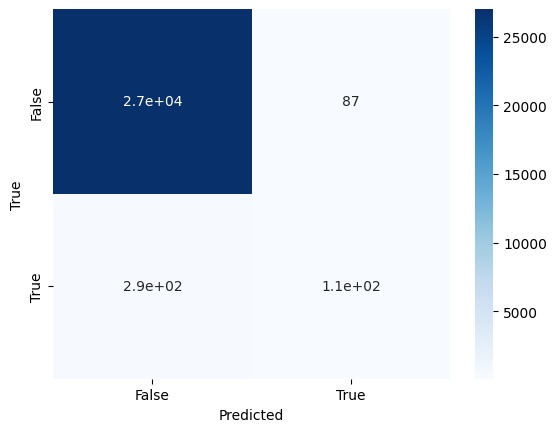

Precision: 0.563
Recall:    0.280
F1 Score:  0.374
Accuracy:  0.986
Clipping 21 genes with -log10(p) > 10


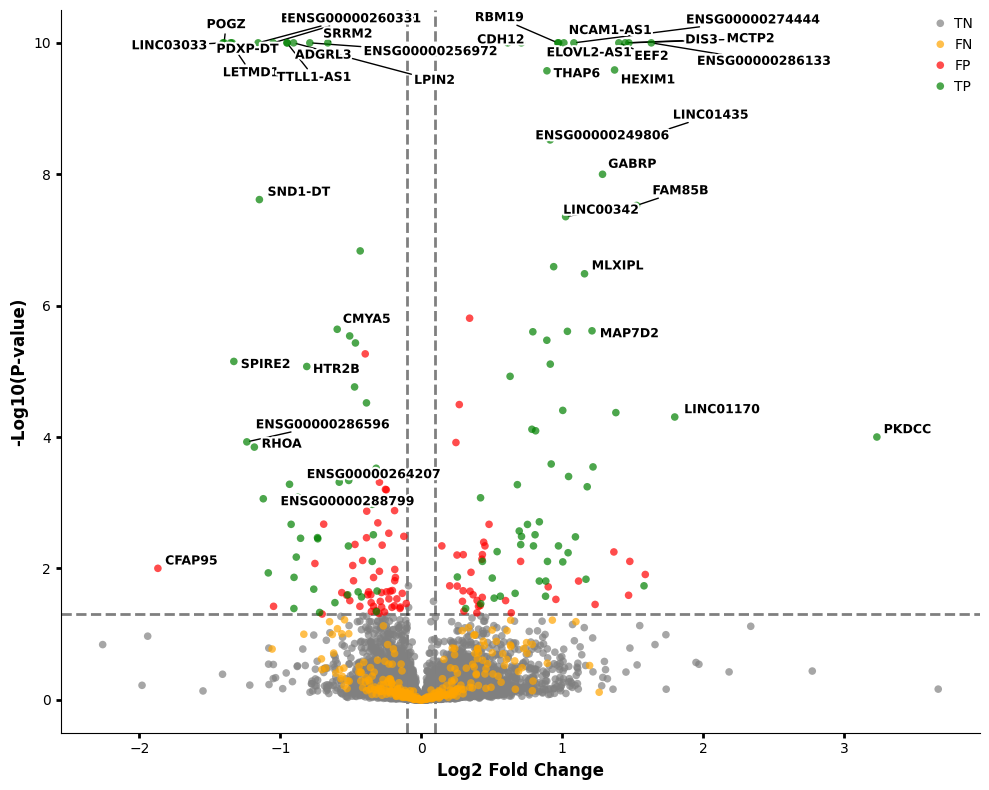

,gene,logFC_case_controlcase,p_case_controlcase,adj_p_case_controlcase,is_significant,is_true_DEG,-log10p,category,sorter
0,A1BG,-0.117213,0.001793,0.133972,False,False,0.872987,TN,-0.102325
1,A1BG-AS1,-0.071951,0.281968,0.819951,False,False,0.086212,TN,-0.006203
2,A1CF,-0.217860,0.025654,0.457762,False,False,0.339360,TN,-0.073933
3,A2M,0.325186,0.149773,0.730648,False,False,0.136292,TN,0.044320
4,A2M-AS1,0.023495,0.696624,0.949352,False,False,0.022573,TN,0.000530
...,...,...,...,...,...,...,...,...,...
27476,ZZEF1,-0.032563,0.196009,0.767911,False,False,0.114689,TN,-0.003735
27477,ZZZ3,0.045020,0.296227,0.827682,False,False,0.082137,TN,0.003698
27478,ENSG00000205653,0.485690,0.471350,0.891927,False,False,0.049671,TN,0.024125
27479,ENSG00000223438,-0.030626,0.960335,0.994888,False,False,0.002226,TN,-0.000068


In [8]:
for dataset in sorted(os.listdir(DATASET_FOLDER)):

    print(f"\n######\n Processing dataset: {dataset} \n######\n")

    results_folder = os.path.join(DATASET_FOLDER, dataset, METHOD_NAME)
    save_csv_path = os.path.join(results_folder, f"{dataset}-{METHOD_NAME}_results.csv")

    df_nebula = pd.read_csv(save_csv_path)

    DEG.plot_nebula_results(df_nebula, 
                    df_true_degs, 
                    col_p=f"p_{CONTRAST_VARIABLE}{CONTRAST_STIM}", 
                    col_logFC=f"logFC_{CONTRAST_VARIABLE}{CONTRAST_STIM}", 
                    col_gene="gene",
                    PVAL_THR=PVAL_THR,
                    LOGFC_THR=LOGFC_THR,
                    max_FDR=10,
                    add_adj_p_col=True
                    )
    break